In [220]:
%load_ext autoreload
%autoreload 2
from tools.emuse_utils import DiscreteLatentSpace
import pickle
import pandas as pd

# Create a DiscreteLatentSpace object with loading /gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav and /gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv

# Load the UMAP embedding to numpy
embedding = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv', header=None)
embedding = embedding.values

# Load the UMAP model
with open('/gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav', 'rb') as f:
    umap_model = pickle.load(f)
    
# Create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(umap_model, embedding, margin=10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


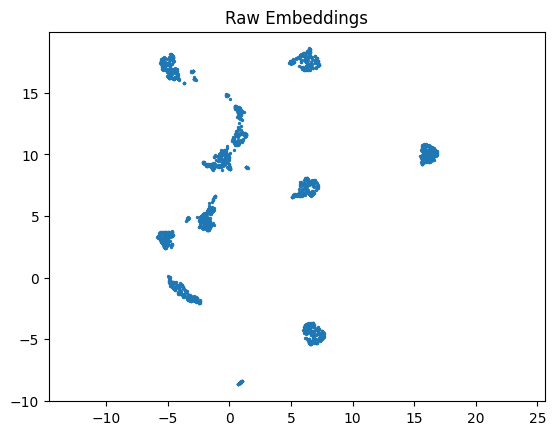

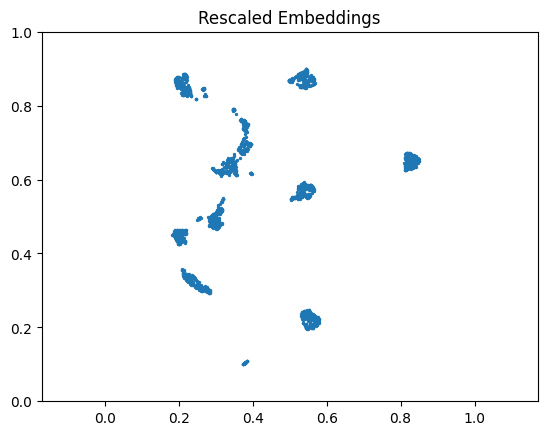

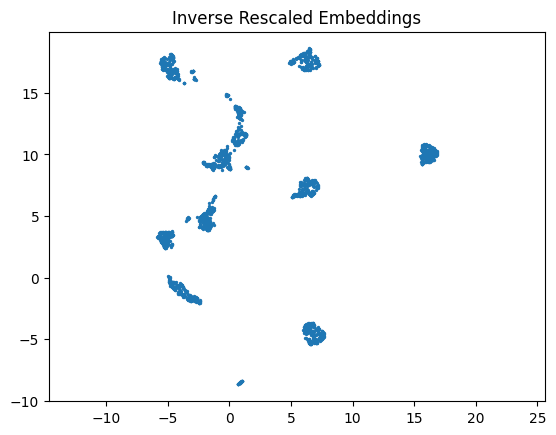

There is an overlap of 9.74% points in the pixelated space
The number of cells in the pixelated space is 917910
The shape of the pixelated space is (930, 987)
Maximum in each dimension: 18.60238075256348


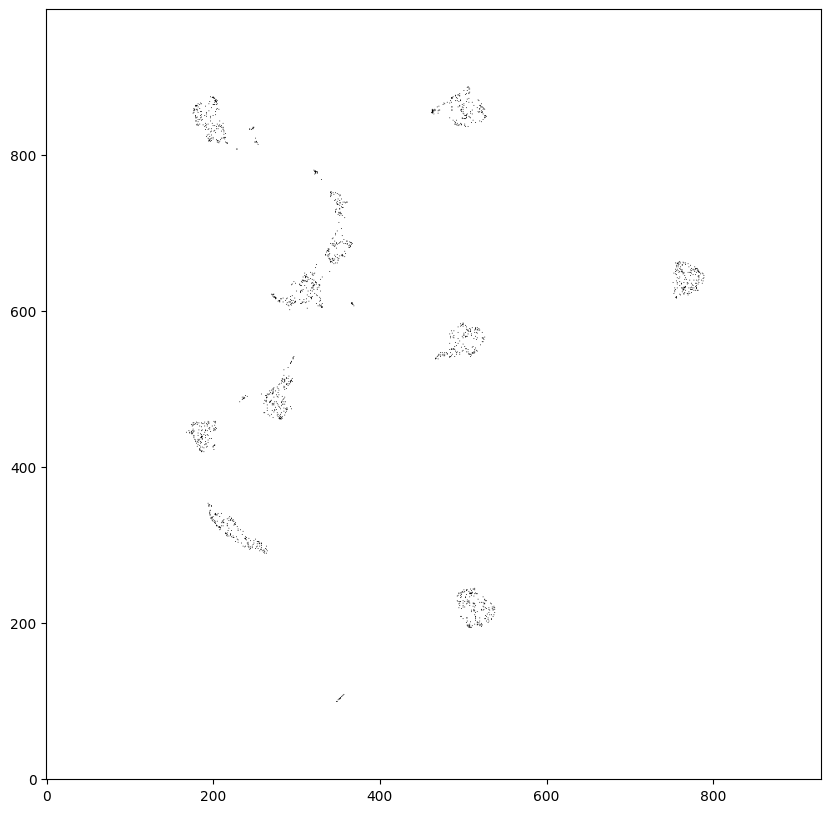

There is an overlap of 11.57% points in the pixelated space
The number of cells in the pixelated space is 722750
The shape of the pixelated space is (826, 875)
Maximum in each dimension: 18.60238075256348


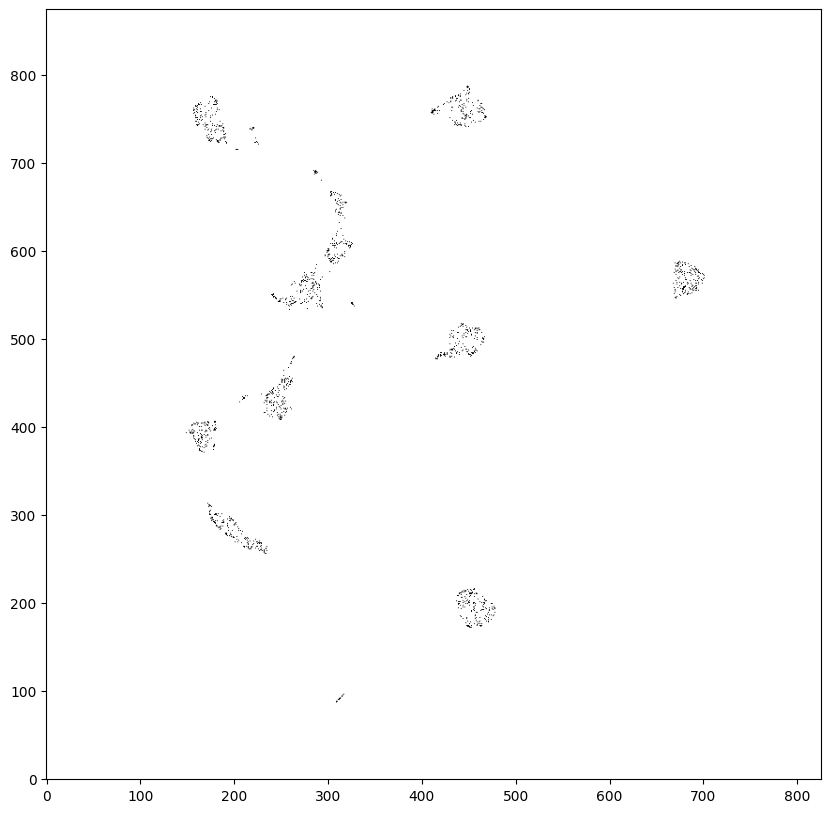

There is an overlap of 11.69% points in the pixelated space
The number of cells in the pixelated space is 722700
The shape of the pixelated space is (825, 876)
Maximum in each dimension: 18.60238075256348


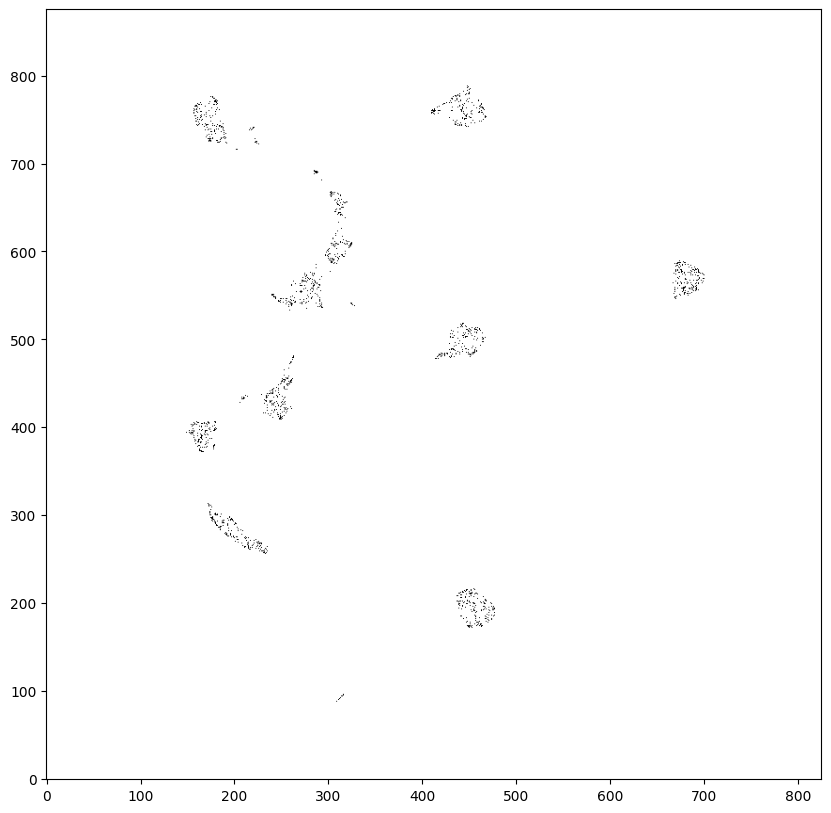

In [223]:
# plot the different versions of the embeddings in the latent space
dls.plot_raw_embedding()

dls.plot_rescaled_embedding()

dls.plot_inverse_rescaled_embedding()

dls.plot_pixelated_embedding(10)

dls.plot_pixelated_embedding(None, (826, 875))
dls.plot_pixelated_embedding(None, (825, 876))


In [186]:
import numpy as np

rescaled_embeddings = dls.rescaled_embeddings

cells_number = 722750

rescaled_maximum_coords = np.max(rescaled_embeddings, axis=0)

if isinstance(cells_number, int):
    dimensions = len(rescaled_maximum_coords)

    # Calculate the aspect ratio
    aspect_ratio = rescaled_maximum_coords / np.max(rescaled_maximum_coords)
    
    print(aspect_ratio)

    # Compute the number of cells in each dimension while maintaining the aspect ratio
    cells_per_dimension = np.round((cells_number ** (1 / dimensions)) * aspect_ratio).astype(int)
else:
    cells_per_dimension = np.array(cells_number)
    
print(cells_per_dimension)



[0.94352951 1.        ]
[802 850]


(826, 875)
